# Projet SM604 - De la classification des chiffres manuscrits à la détection de cancers du sein
## Mathématiques pour le Machine Learning - EFREI Paris 2025-2026
### Sabrina El Hassani, Aude Labat, Thomas Duriaud, Paul Fontaine, Evan Ladeira

---

## Partie 3 - Application au diagnostic médical (CBIS-DDSM)

Ce notebook est organisé en quatre sections :

**Section 3.1** Chargement et prétraitement du dataset CBIS-DDSM

**Section 3.2** Architectures denses (linéaire, H=1, H=2) adaptées à la classification binaire

**Section 3.3** CNN adapté au diagnostic médical (Option B : PyTorch)

**Section 3.4** Analyse de la matrice de confusion et discussion médicale

---

**Structure du dataset Kaggle (`awsaf49/cbis-ddsm-breast-cancer-image-dataset`) :**
```
cbis-ddsm-breast-cancer-image-dataset/
├── csv/
│   ├── mass_case_description_train_set.csv
│   ├── mass_case_description_test_set.csv
│   └── dicom_info.csv                  <- table de correspondance clé
└── jpeg/
    └── 1.3.6.1.4.1.9590.100.1.2.XXX/  <- dossiers nommés par UID
        └── 1-211.jpg
```

**Stratégie de chargement :**  
Le CSV masse référence les images par un chemin DICOM (`.dcm`).  
`dicom_info.csv` fait le lien entre ces UIDs et les vrais fichiers `.jpg` sur disque.  
On jointure les deux sur le `SeriesInstanceUID` (3ème segment du chemin DICOM).

**Objectif :** classification binaire **bénin (0) vs malin (1)**.  
- `BENIGN` + `BENIGN_WITHOUT_CALLBACK` → **0**  
- `MALIGNANT` → **1**

---
## Section 3.1 - Chargement et prétraitement de CBIS-DDSM

### Imports

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from PIL import Image
from sklearn.metrics import confusion_matrix

np.random.seed(42)
torch.manual_seed(42)
print("Imports OK")

Imports OK


### Chemins du dataset

**Deux chemins à adapter :**
- `CSV_DIR`  : dossier contenant les fichiers `.csv`
- `JPEG_DIR` : dossier contenant les sous-dossiers `1.3.6.1.4.1.9590.xxx/`

In [2]:
# --- Adapter ces deux chemins ---
CSV_DIR  = "C:/Users/audel/Documents/csv"    # dossier contenant les .csv
JPEG_DIR = "C:/Users/audel/Documents/jpeg"   # dossier contenant les sous-dossiers 1.3.6...
IMG_SIZE = 128

for d in [CSV_DIR, JPEG_DIR]:
    print(f"  {d} : {'OK' if os.path.isdir(d) else 'INTROUVABLE'}")

  C:/Users/audel/Documents/csv : OK
  C:/Users/audel/Documents/jpeg : OK


### Chargement des données

**Pourquoi `dicom_info.csv` ?**  
Le CSV masse référence les images avec des chemins DICOM (`.dcm`) de la forme :  
`Mass-Training_P_00001_LEFT_CC / UID_serie / UID_instance / 000000.dcm`  

Les fichiers sur disque sont des `.jpg` dans des dossiers nommés par UID.  
`dicom_info.csv` contient pour chaque image : son `SeriesInstanceUID` ET son chemin `.jpg` réel.  
On extrait le 3ème segment du chemin DICOM (= `UID_instance` = `SeriesInstanceUID`) pour faire la jointure.

In [3]:
def charger_cbis(csv_masse, csv_dicom, jpeg_dir, taille=128):
    """
    Charge et prepare le dataset CBIS-DDSM en une seule fonction.

    Strategie :
    1. Lire le CSV masse (pathology + chemin DICOM)
    2. Extraire le SeriesInstanceUID (3e segment du chemin DICOM)
    3. Joindre avec dicom_info.csv pour obtenir le chemin .jpg reel
    4. Charger chaque image, la convertir en niveaux de gris, la redimensionner

    csv_masse : str, chemin vers mass_case_description_train/test_set.csv
    csv_dicom : str, chemin vers dicom_info.csv
    jpeg_dir  : str, dossier racine des images JPEG
    taille    : int, cote du carre cible (128x128)
    Retourne  : X array (n, taille, taille) float32, y array (n,) int
    """

    # Etape 1 : lecture des CSV
    df_masse = pd.read_csv(csv_masse)
    df_dicom = pd.read_csv(csv_dicom)

    # Etape 2 : binarisation de la pathologie
    def label(p):
        p = str(p).strip().upper()
        if p in ["BENIGN", "BENIGN_WITHOUT_CALLBACK"]: return 0
        if p == "MALIGNANT": return 1
        return -1

    df_masse["label"] = df_masse["pathology"].apply(label)
    df_masse = df_masse[df_masse["label"] != -1].reset_index(drop=True)

    # Etape 3 : extraction du SeriesInstanceUID
    # chemin DICOM = 'Mass-Training_P_XXXXX / UID_serie / UID_instance / 000000.dcm'
    # Le 3e segment (index 2) = UID_instance = SeriesInstanceUID dans dicom_info
    df_masse["UID_instance"] = df_masse["image file path"].apply(
        lambda p: p.replace("\\", "/").split("/")[2]
    )

    # Etape 4 : jointure avec dicom_info pour obtenir le chemin .jpg
    # On garde uniquement les full mammogram images (pas les crops ni les masques)
    df_full = df_dicom[
        df_dicom["SeriesDescription"].str.contains("full", case=False, na=False)
    ][["SeriesInstanceUID", "image_path"]].drop_duplicates("SeriesInstanceUID")

    df_masse = df_masse.merge(
        df_full, left_on="UID_instance", right_on="SeriesInstanceUID", how="left"
    )
    df_masse = df_masse[df_masse["image_path"].notna()].reset_index(drop=True)

    # image_path = 'CBIS-DDSM/jpeg/UID/fichier.jpg'
    # -> on extrait 'UID/fichier.jpg' et on prefixe avec jpeg_dir
    df_masse["chemin_jpeg"] = df_masse["image_path"].apply(
        lambda p: os.path.join(jpeg_dir, "/".join(str(p).replace("\\", "/").split("/")[-2:]))
    )

    # Deduplication : une mammographie = une ligne
    df_masse = df_masse.drop_duplicates(subset="chemin_jpeg").reset_index(drop=True)
    print(f"  {len(df_masse)} images uniques | "
          f"Benin={int((df_masse['label']==0).sum())}  "
          f"Malin={int((df_masse['label']==1).sum())}")

    # Etape 5 : chargement des images
    images, labels = [], []
    n_manquantes   = 0

    for i, row in df_masse.iterrows():
        try:
            img = Image.open(row["chemin_jpeg"]).convert("L")      # niveaux de gris
            img = img.resize((taille, taille), Image.BICUBIC)      # 128x128
            images.append(np.array(img, dtype=np.float32) / 255.0) # normalisation [0,1]
            labels.append(row["label"])
        except Exception:
            n_manquantes += 1

        if (i + 1) % 100 == 0:
            print(f"    {len(images)} chargees...", end="\r")

    if n_manquantes > 0:
        print(f"    {n_manquantes} fichiers introuvables (verifier JPEG_DIR)")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=int)


print("Chargement du train...")
X_raw_train, y_train = charger_cbis(
    os.path.join(CSV_DIR, "mass_case_description_train_set.csv"),
    os.path.join(CSV_DIR, "dicom_info.csv"),
    JPEG_DIR, taille=IMG_SIZE
)

print("\nChargement du test...")
X_raw_test, y_test = charger_cbis(
    os.path.join(CSV_DIR, "mass_case_description_test_set.csv"),
    os.path.join(CSV_DIR, "dicom_info.csv"),
    JPEG_DIR, taille=IMG_SIZE
)

print(f"\nTrain : {X_raw_train.shape}  |  Test : {X_raw_test.shape}")
print(f"Pixels : min={X_raw_train.min():.3f}  max={X_raw_train.max():.3f}")

Chargement du train...
  1231 images uniques | Benin=634  Malin=597
    1200 chargees...
Chargement du test...
  361 images uniques | Benin=218  Malin=143
    300 chargees...
Train : (1231, 128, 128)  |  Test : (361, 128, 128)
Pixels : min=0.000  max=1.000


### Visualisation des mammographies

On affiche quelques images de chaque classe pour vérifier le chargement.  
Contrairement à MNIST (chiffres nets sur fond noir) ou CIFAR-10 (objets colorés 32×32),  
les mammographies présentent des textures subtiles et une grande variabilité entre patients.

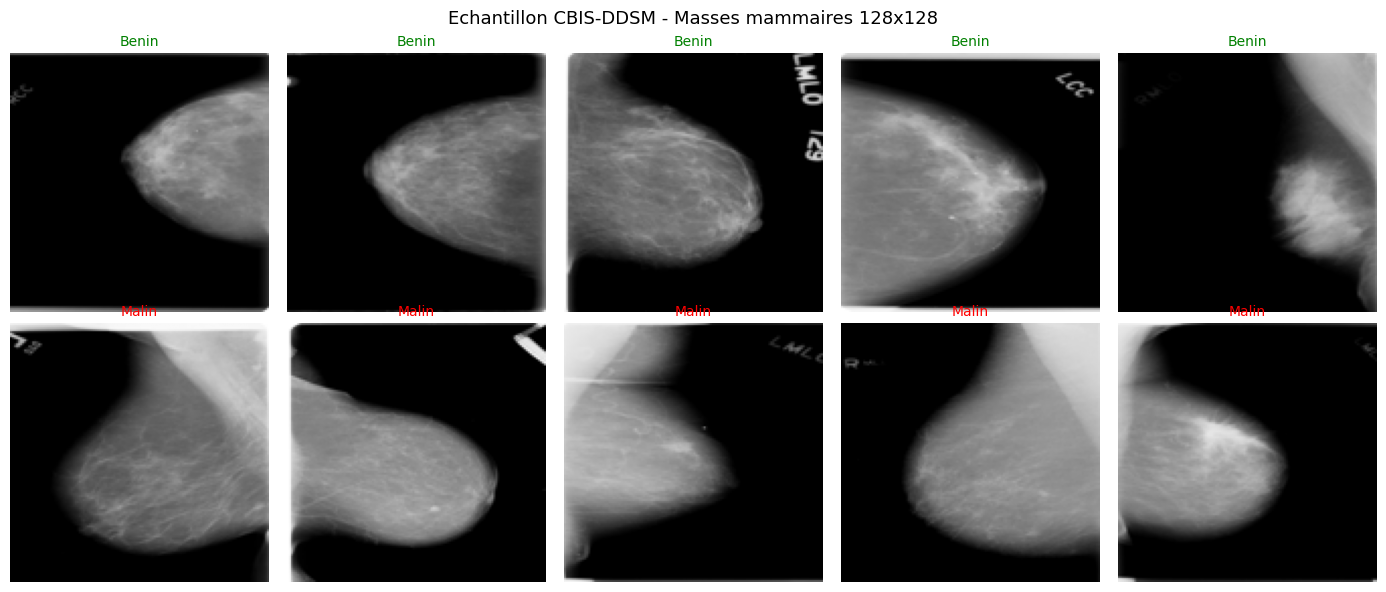

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for classe, titre, couleur in [(0, "Benin", "green"), (1, "Malin", "red")]:
    indices_classe = np.where(y_train == classe)[0]
    echantillon    = np.random.choice(indices_classe, size=5, replace=False)
    for j, idx in enumerate(echantillon):
        ax = axes[classe][j]
        ax.imshow(X_raw_train[idx], cmap="gray", vmin=0, vmax=1)
        ax.set_title(titre, fontsize=10, color=couleur)
        ax.axis("off")

plt.suptitle("Echantillon CBIS-DDSM - Masses mammaires 128x128", fontsize=13)
plt.tight_layout()
plt.savefig("cbis_echantillon.png", dpi=100, bbox_inches="tight")
plt.show()

### Préparation des données pour les modèles denses

On aplatit chaque image 128×128 en vecteur $\vec{x} \in \mathbb{R}^{16384}$ (car $128 \times 128 = 16\,384$).  
On adapte le one-hot à **C=2** classes et on calcule les poids de déséquilibre pour le CNN.

$$w_c = \frac{n_{\text{total}}}{2 \cdot n_c}$$

In [5]:
N_PIXELS = IMG_SIZE * IMG_SIZE   # 16 384

def one_hot(y, C=2):
    """
    Convertit les etiquettes entieres en matrice one-hot.
    y=0 donne [1, 0]  (benin)
    y=1 donne [0, 1]  (malin)

    y : array (n,) entiers entre 0 et C-1
    Retourne Y : array (n, C)
    """
    n = len(y)
    Y = np.zeros((n, C))
    Y[np.arange(n), y] = 1.0
    return Y


# Aplatissement : (n, 128, 128) -> (n, 16384)
X_train_flat = X_raw_train.reshape(len(X_raw_train), -1)
X_test_flat  = X_raw_test.reshape(len(X_raw_test),  -1)

# One-hot binaire C=2
Y_train_oh = one_hot(y_train, C=2)
Y_test_oh  = one_hot(y_test,  C=2)

# Poids de desequilibre pour la CrossEntropyLoss ponderee (CNN)
n_total_tr = len(y_train)
n_benin_tr = int((y_train == 0).sum())
n_malin_tr = int((y_train == 1).sum())
w_benin    = n_total_tr / (2 * n_benin_tr)
w_malin    = n_total_tr / (2 * n_malin_tr)

print(f"X_train_flat : {X_train_flat.shape}")
print(f"X_test_flat  : {X_test_flat.shape}")
print(f"\nDistribution train : Benin={n_benin_tr}  Malin={n_malin_tr}")
print(f"Poids de classe    : w_benin={w_benin:.3f}  w_malin={w_malin:.3f}")
print(f"Rapport            : une erreur sur un malin penalisee {w_malin/w_benin:.1f}x plus")

class_weights_torch = torch.tensor([w_benin, w_malin], dtype=torch.float32)

X_train_flat : (1231, 16384)
X_test_flat  : (361, 16384)

Distribution train : Benin=634  Malin=597
Poids de classe    : w_benin=0.971  w_malin=1.031
Rapport            : une erreur sur un malin penalisee 1.1x plus


---
## Section 3.2 - Architectures denses adaptées à la classification binaire

On réutilise exactement les mêmes architectures que les Parties 1 et 2, avec deux adaptations :  
- **C = 2** classes au lieu de 10  
- **n_input = 16 384** au lieu de 784 (MNIST) ou 1024/3072 (CIFAR-10)

Le learning rate est réduit à 0.01 (vs 0.1 sur MNIST) car le dataset est bien plus petit.

### Fonctions communes (softmax, cross-entropy, ReLU)

In [6]:
def softmax_python(o):
    """
    Transforme les scores bruts en probabilites.
    Soustrait le max avant l'exponentielle pour la stabilite numerique.

    o : array (n, C)
    Retourne P : array (n, C), chaque ligne somme a 1
    """
    o = np.array(o)
    resultats = []
    for image in o:
        max_score      = max(image)
        scores_stables = [s - max_score for s in image]
        exp_scores     = [math.exp(s) for s in scores_stables]
        somme          = sum(exp_scores)
        probas         = [e / somme for e in exp_scores]
        resultats.append(probas)
    return np.array(resultats)


def cross_entropy(P, Y):
    """
    Mesure l'erreur moyenne entre probabilites predites et vraies etiquettes.
    Grace au one-hot, seul le log de la vraie classe compte par image.

    P : (n, C) probabilites predites
    Y : (n, C) etiquettes one-hot
    Retourne un scalaire
    """
    n = len(P)
    C = Y.shape[1]
    total = 0
    for i in range(n):
        for k in range(C):
            if Y[i][k] == 1:
                p = max(P[i][k], 1e-12)
                total += math.log(p)
                break
    return -total / n


def error_rate(P, y_true):
    """
    Proportion d'images mal classees.

    P      : (n, C) probabilites predites
    y_true : (n,) etiquettes entieres
    Retourne un scalaire entre 0 et 1
    """
    n = len(y_true)
    erreurs = 0
    for i in range(n):
        if int(np.argmax(P[i])) != y_true[i]:
            erreurs += 1
    return erreurs / n


def relu(x):
    """
    Applique ReLU element par element : max(0, x).
    Met les valeurs negatives a 0, garde les positives.
    Sans cette non-linearite, deux couches lineaires s'effondrent en une seule.

    x : array de shape quelconque
    Retourne un array de meme shape
    """
    return np.maximum(0, x)


def relu_derivative(x):
    """
    Derivee de ReLU : 1 si x > 0, 0 sinon.
    Utilisee dans la retropropagation pour bloquer le gradient
    la ou ReLU a eteint le neurone.

    x : array de shape quelconque
    Retourne un array de meme shape, valeurs 0 ou 1
    """
    return (x > 0).astype(float)


print("Fonctions communes chargees.")

Fonctions communes chargees.


### Modèle linéaire

Architecture : $\vec{o} = A\vec{x} + b$ avec $A \in \mathbb{R}^{2 \times 16384}$, $b \in \mathbb{R}^{2}$.  
Nombre de paramètres : $2 \times 16384 + 2 = 32\,770$.

**Gradient :**
$$\nabla_A L = \frac{1}{n}(P-Y)^T X \qquad \nabla_b L = \frac{1}{n}\sum_{\text{lignes}}(P-Y)$$

In [7]:
def train_linear(X_train, Y_train, y_train, X_test, y_test,
                 n_input, n_classes=2, lr=0.01, batch_size=32, seuil=1e-4, max_epochs=500):
    """
    Descente de gradient par mini-batches avec early stopping.

    n_input    : dimension de l'entree (16384 pour 128x128)
    n_classes  : nombre de classes (2 pour classification binaire)
    lr         : learning rate eta
    batch_size : images par mini-batch
    seuil      : arret si |loss[t] - loss[t-1]| < seuil
    max_epochs : securite contre boucle infinie
    """
    A = np.random.randn(n_classes, n_input) * 0.01
    b = np.zeros(n_classes)
    n = len(X_train)
    epoch    = 0
    converge = False

    hist_loss, hist_train, hist_test = [], [], []

    while not converge:

        # Melange : toutes les images vues dans un ordre different a chaque epoch
        indices = np.random.permutation(n)
        X_s = X_train[indices]
        Y_s = Y_train[indices]

        for start in range(0, n, batch_size):
            X_b = X_s[start : start+batch_size]
            Y_b = Y_s[start : start+batch_size]

            # Passe avant
            o   = X_b @ A.T + b
            P_b = softmax_python(o)

            # Gradient : delta = P - Y
            delta = P_b - Y_b
            dA    = (delta.T @ X_b) / len(X_b)
            db    = delta.mean(axis=0)

            A -= lr * dA
            b -= lr * db

        # Evaluation fin d'epoch
        P_train = softmax_python(X_train @ A.T + b)
        P_test  = softmax_python(X_test  @ A.T + b)

        loss      = cross_entropy(P_train, Y_train)
        err_train = error_rate(P_train, y_train)
        err_test  = error_rate(P_test,  y_test)

        hist_loss.append(loss)
        hist_train.append(err_train)
        hist_test.append(err_test)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss={loss:.4f} | "
                  f"Train={err_train*100:.2f}% | Test={err_test*100:.2f}%")

        if epoch > 0:
            diff = abs(hist_loss[-2] - hist_loss[-1])
            if diff < seuil:
                print(f"\nConverge a l'epoch {epoch} (diff={diff:.8f})")
                converge = True
            elif epoch > 5:
                if all(hist_test[-i] > hist_test[-i-1] for i in range(1, 5)):
                    print(f"\nEarly stopping epoch {epoch} : overfitting detecte")
                    converge = True

        if epoch >= max_epochs:
            print(f"\nArret : {max_epochs} epochs atteintes")
            converge = True

        epoch += 1

    return A, b, hist_loss, hist_train, hist_test

In [8]:
np.random.seed(42)
print("=" * 55)
print(f"Modele lineaire - CBIS-DDSM | Parametres : {2*N_PIXELS + 2:,}")
print("=" * 55)

A_lin, b_lin, losses_lin, etr_lin, ete_lin = train_linear(
    X_train_flat, Y_train_oh, y_train,
    X_test_flat,  y_test,
    n_input=N_PIXELS, n_classes=2, lr=0.01, batch_size=32, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_lin[-1]*100:.2f}%  |  Test : {ete_lin[-1]*100:.2f}%  |  Ecart : {abs(etr_lin[-1]-ete_lin[-1])*100:.2f}%")

Modele lineaire - CBIS-DDSM | Parametres : 32,770
Epoch   0 | Loss=1.2171 | Train=49.31% | Test=57.34%
Epoch  10 | Loss=1.4563 | Train=47.85% | Test=57.62%

Early stopping epoch 11 : overfitting detecte

Resultat final :
  Train : 49.39%  |  Test : 58.17%  |  Ecart : 8.78%


### Modèle H=1

Architecture : une couche cachée de 128 neurones avec ReLU.  
Nombre de paramètres : $128 \times 16384 + 128 + 2 \times 128 + 2 = 2\,098\,818$.

**Rétropropagation H=1 :**
$$\delta^2 = P - Y \qquad \nabla_{A^2} L = \frac{1}{n} (\delta^2)^T z^1 \qquad \nabla_{b^2} L = \frac{1}{n}\sum \delta^2$$
$$\delta^1 = (\delta^2 \cdot A^2) \times \text{ReLU}'(o^1) \qquad \nabla_{A^1} L = \frac{1}{n} (\delta^1)^T X \qquad \nabla_{b^1} L = \frac{1}{n}\sum \delta^1$$

In [9]:
def train_h1(X_train, Y_train, y_train, X_test, y_test,
             n_input, p1=128, n_classes=2, lr=0.01, batch_size=32, seuil=1e-4, max_epochs=500):
    """
    Entrainement du modele H=1 par descente de gradient mini-batches.

    n_input    : dimension de l'entree
    p1         : nombre de neurones dans la couche cachee
    n_classes  : nombre de classes
    lr         : learning rate
    batch_size : images par mini-batch
    seuil      : arret si |loss[t] - loss[t-1]| < seuil
    max_epochs : securite contre boucle infinie
    """
    A1 = np.random.randn(p1, n_input)   * 0.01
    b1 = np.zeros(p1)
    A2 = np.random.randn(n_classes, p1) * 0.01
    b2 = np.zeros(n_classes)
    n  = len(X_train)
    epoch    = 0
    converge = False

    hist_loss, hist_train, hist_test = [], [], []

    while not converge:

        indices = np.random.permutation(n)
        X_s = X_train[indices]
        Y_s = Y_train[indices]

        for start in range(0, n, batch_size):
            X_b = X_s[start : start+batch_size]
            Y_b = Y_s[start : start+batch_size]

            # Forward
            o1  = X_b @ A1.T + b1
            z1  = relu(o1)
            o2  = z1  @ A2.T + b2
            P_b = softmax_python(o2)

            # Backward
            delta2 = P_b - Y_b
            dA2    = (delta2.T @ z1) / len(X_b)
            db2    = delta2.mean(axis=0)
            delta1 = (delta2 @ A2) * relu_derivative(o1)
            dA1    = (delta1.T @ X_b) / len(X_b)
            db1    = delta1.mean(axis=0)

            A1 -= lr * dA1
            b1 -= lr * db1
            A2 -= lr * dA2
            b2 -= lr * db2

        # Evaluation fin d'epoch
        z1_tr   = relu(X_train @ A1.T + b1)
        P_train = softmax_python(z1_tr @ A2.T + b2)
        z1_te   = relu(X_test  @ A1.T + b1)
        P_test  = softmax_python(z1_te @ A2.T + b2)

        loss      = cross_entropy(P_train, Y_train)
        err_train = error_rate(P_train, y_train)
        err_test  = error_rate(P_test,  y_test)

        hist_loss.append(loss)
        hist_train.append(err_train)
        hist_test.append(err_test)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss={loss:.4f} | "
                  f"Train={err_train*100:.2f}% | Test={err_test*100:.2f}%")

        if epoch > 0:
            diff = abs(hist_loss[-2] - hist_loss[-1])
            if diff < seuil:
                print(f"\nConverge a l'epoch {epoch} (diff={diff:.8f})")
                converge = True
            elif epoch > 5:
                if all(hist_test[-i] > hist_test[-i-1] for i in range(1, 5)):
                    print(f"\nEarly stopping epoch {epoch} : overfitting detecte")
                    converge = True

        if epoch >= max_epochs:
            print(f"\nArret : {max_epochs} epochs atteintes")
            converge = True

        epoch += 1

    return A1, b1, A2, b2, hist_loss, hist_train, hist_test

In [10]:
np.random.seed(42)
print("=" * 55)
print(f"Modele H=1 - CBIS-DDSM (p1=128) | Parametres : {128*N_PIXELS+128+2*128+2:,}")
print("=" * 55)

A1_h1, b1_h1, A2_h1, b2_h1, losses_h1, etr_h1, ete_h1 = train_h1(
    X_train_flat, Y_train_oh, y_train,
    X_test_flat,  y_test,
    n_input=N_PIXELS, p1=128, n_classes=2, lr=0.01, batch_size=32, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_h1[-1]*100:.2f}%  |  Test : {ete_h1[-1]*100:.2f}%  |  Ecart : {abs(etr_h1[-1]-ete_h1[-1])*100:.2f}%")

Modele H=1 - CBIS-DDSM (p1=128) | Parametres : 2,097,538
Epoch   0 | Loss=0.6907 | Train=43.05% | Test=38.23%
Epoch  10 | Loss=0.6565 | Train=37.69% | Test=38.78%
Epoch  20 | Loss=0.6231 | Train=33.14% | Test=34.63%
Epoch  30 | Loss=0.6031 | Train=33.87% | Test=38.50%
Epoch  40 | Loss=0.5586 | Train=26.73% | Test=34.90%
Epoch  50 | Loss=0.5371 | Train=25.67% | Test=40.72%

Arret : 50 epochs atteintes

Resultat final :
  Train : 25.67%  |  Test : 40.72%  |  Ecart : 15.05%


### Modèle H=2

Architecture : deux couches cachées (128 puis 64 neurones) avec ReLU.  
Nombre de paramètres : $128 \times 16384 + 128 + 64 \times 128 + 64 + 2 \times 64 + 2 = 2\,107\,330$.

In [11]:
def train_h2(X_train, Y_train, y_train, X_test, y_test,
             n_input, p1=128, p2=64, n_classes=2, lr=0.01, batch_size=32, seuil=1e-4, max_epochs=500):
    """
    Entrainement du modele H=2 par descente de gradient mini-batches.

    n_input    : dimension de l'entree
    p1, p2     : nombre de neurones dans les deux couches cachees
    n_classes  : nombre de classes
    lr         : learning rate
    batch_size : images par mini-batch
    seuil      : arret si |loss[t] - loss[t-1]| < seuil
    max_epochs : securite contre boucle infinie
    """
    A1 = np.random.randn(p1, n_input)   * 0.01
    b1 = np.zeros(p1)
    A2 = np.random.randn(p2, p1)        * 0.01
    b2 = np.zeros(p2)
    A3 = np.random.randn(n_classes, p2) * 0.01
    b3 = np.zeros(n_classes)
    n  = len(X_train)
    epoch    = 0
    converge = False

    hist_loss, hist_train, hist_test = [], [], []

    while not converge:

        indices = np.random.permutation(n)
        X_s = X_train[indices]
        Y_s = Y_train[indices]

        for start in range(0, n, batch_size):
            X_b = X_s[start : start+batch_size]
            Y_b = Y_s[start : start+batch_size]

            # Forward
            o1  = X_b @ A1.T + b1
            z1  = relu(o1)
            o2  = z1  @ A2.T + b2
            z2  = relu(o2)
            o3  = z2  @ A3.T + b3
            P_b = softmax_python(o3)

            # Backward
            delta3 = P_b - Y_b
            dA3    = (delta3.T @ z2) / len(X_b)
            db3    = delta3.mean(axis=0)
            delta2 = (delta3 @ A3) * relu_derivative(o2)
            dA2    = (delta2.T @ z1) / len(X_b)
            db2    = delta2.mean(axis=0)
            delta1 = (delta2 @ A2) * relu_derivative(o1)
            dA1    = (delta1.T @ X_b) / len(X_b)
            db1    = delta1.mean(axis=0)

            A1 -= lr * dA1
            b1 -= lr * db1
            A2 -= lr * dA2
            b2 -= lr * db2
            A3 -= lr * dA3
            b3 -= lr * db3

        # Evaluation fin d'epoch
        z1_tr   = relu(X_train @ A1.T + b1)
        z2_tr   = relu(z1_tr   @ A2.T + b2)
        P_train = softmax_python(z2_tr @ A3.T + b3)
        z1_te   = relu(X_test  @ A1.T + b1)
        z2_te   = relu(z1_te   @ A2.T + b2)
        P_test  = softmax_python(z2_te @ A3.T + b3)

        loss      = cross_entropy(P_train, Y_train)
        err_train = error_rate(P_train, y_train)
        err_test  = error_rate(P_test,  y_test)

        hist_loss.append(loss)
        hist_train.append(err_train)
        hist_test.append(err_test)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss={loss:.4f} | "
                  f"Train={err_train*100:.2f}% | Test={err_test*100:.2f}%")

        if epoch > 0:
            diff = abs(hist_loss[-2] - hist_loss[-1])
            if diff < seuil:
                print(f"\nConverge a l'epoch {epoch} (diff={diff:.8f})")
                converge = True
            elif epoch > 5:
                if all(hist_test[-i] > hist_test[-i-1] for i in range(1, 5)):
                    print(f"\nEarly stopping epoch {epoch} : overfitting detecte")
                    converge = True

        if epoch >= max_epochs:
            print(f"\nArret : {max_epochs} epochs atteintes")
            converge = True

        epoch += 1

    return A1, b1, A2, b2, A3, b3, hist_loss, hist_train, hist_test

In [12]:
np.random.seed(42)
print("=" * 60)
print(f"Modele H=2 - CBIS-DDSM (p1=128, p2=64) | Parametres : {128*N_PIXELS+128+64*128+64+2*64+2:,}")
print("=" * 60)

A1_h2, b1_h2, A2_h2, b2_h2, A3_h2, b3_h2, losses_h2, etr_h2, ete_h2 = train_h2(
    X_train_flat, Y_train_oh, y_train,
    X_test_flat,  y_test,
    n_input=N_PIXELS, p1=128, p2=64, n_classes=2, lr=0.01, batch_size=32, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_h2[-1]*100:.2f}%  |  Test : {ete_h2[-1]*100:.2f}%  |  Ecart : {abs(etr_h2[-1]-ete_h2[-1])*100:.2f}%")

Modele H=2 - CBIS-DDSM (p1=128, p2=64) | Parametres : 2,105,666
Epoch   0 | Loss=0.6930 | Train=48.50% | Test=39.61%

Converge a l'epoch 1 (diff=0.00009008)

Resultat final :
  Train : 48.50%  |  Test : 39.61%  |  Ecart : 8.88%


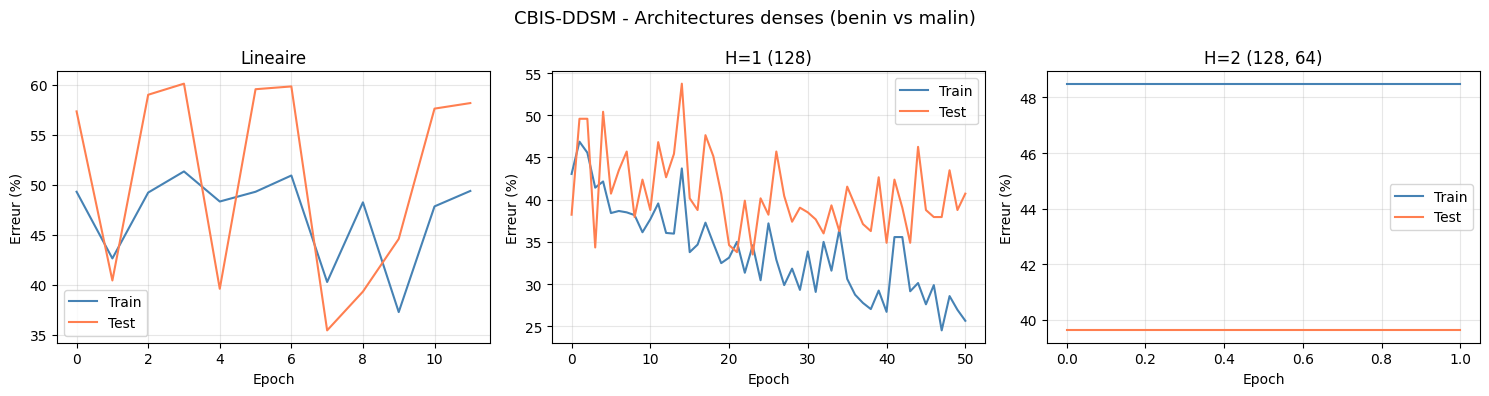

In [13]:
# Courbes d'erreur train/test pour les 3 architectures denses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titres  = ["Lineaire", "H=1 (128)", "H=2 (128, 64)"]
donnees = [(etr_lin, ete_lin), (etr_h1, ete_h1), (etr_h2, ete_h2)]

for ax, titre, (etr, ete) in zip(axes, titres, donnees):
    ax.plot([e*100 for e in etr], label="Train", color="steelblue")
    ax.plot([e*100 for e in ete], label="Test",  color="coral")
    ax.set_title(titre)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Erreur (%)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("CBIS-DDSM - Architectures denses (benin vs malin)", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_cbis_dense.png", dpi=100, bbox_inches="tight")
plt.show()

---
## Section 3.3 - CNN adapté au diagnostic médical (Option B : PyTorch)

On adapte l'architecture CNN de la Partie 2 à ce problème binaire sur images en niveaux de gris 128×128.

**Différences par rapport au CNN CIFAR-10 :**

| | CNN CIFAR-10 | CNN CBIS-DDSM |
|---|---|---|
| Entree | (N, **3**, 32, 32) RGB | (N, **1**, 128, 128) niveaux de gris |
| Sortie | 10 classes | **2** classes (benin/malin) |
| Max-poolings | 2 | **3** (image plus grande) |
| Flatten | 8×8×64 = 4096 | 16×16×64 = **16 384** |
| Regularisation | aucune | **Dropout(0.5)** (peu de donnees) |
| Fonction de cout | CrossEntropyLoss | CrossEntropyLoss(**ponderee**) |

In [14]:
class CNN_CBIS(nn.Module):
    """
    CNN pour la classification binaire de mammographies CBIS-DDSM.
    Entree  : (batch, 1, 128, 128) image en niveaux de gris normalisee entre 0 et 1
    Sortie  : (batch, 2) logits bruts (CrossEntropyLoss integre le softmax)

    Architecture :
    - Bloc 1 : Conv(1->32) + Conv(32->32) + MaxPool -> (32, 64, 64)
    - Bloc 2 : Conv(32->64) + Conv(64->64) + MaxPool -> (64, 32, 32)
    - Bloc 3 : Conv(64->64) + MaxPool -> (64, 16, 16)
    - Flatten : 64x16x16 = 16 384 valeurs
    - Dropout(0.5) + Linear(16384 -> 2)
    """
    def __init__(self):
        super(CNN_CBIS, self).__init__()

        # Bloc 1 : 1 canal gris en entree, 32 cartes de caracteristiques
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)   # 128x128 -> 64x64

        # Bloc 2 : 32 -> 64 cartes, capture des motifs plus abstraits
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)   # 64x64 -> 32x32

        # Bloc 3 : 64 cartes supplementaires pour les textures fines des mammographies
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)   # 32x32 -> 16x16

        # Tete de classification : 16x16x64 = 16384 -> 2 classes
        self.dropout = nn.Dropout(p=0.5)        # regularisation contre l'overfitting
        self.fc      = nn.Linear(16 * 16 * 64, 2)
        self.relu    = nn.ReLU()

    def forward(self, x):
        """
        Passage avant : chemin des donnees a travers les couches.
        x entree : (batch, 1, 128, 128)
        """
        x = self.relu(self.conv1(x))   # (batch, 32, 128, 128)
        x = self.relu(self.conv2(x))   # (batch, 32, 128, 128)
        x = self.pool1(x)              # (batch, 32, 64, 64)

        x = self.relu(self.conv3(x))   # (batch, 64, 64, 64)
        x = self.relu(self.conv4(x))   # (batch, 64, 64, 64)
        x = self.pool2(x)              # (batch, 64, 32, 32)

        x = self.relu(self.conv5(x))   # (batch, 64, 32, 32)
        x = self.pool3(x)              # (batch, 64, 16, 16)

        x = torch.flatten(x, 1)        # (batch, 16384)
        x = self.dropout(x)            # eteint 50% des neurones pendant l'entrainement
        x = self.fc(x)                 # (batch, 2) logits bruts
        return x


# Verification de l'architecture
model_cnn = CNN_CBIS()
n_params  = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(model_cnn)
print(f"\nTotal parametres entrainables : {n_params:,}")

# Test avec un batch fictif
x_fictif = torch.randn(4, 1, 128, 128)
sortie   = model_cnn(x_fictif)
print(f"Test forward : entree {list(x_fictif.shape)} -> sortie {list(sortie.shape)}")

CNN_CBIS(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=16384, out_features=2, bias=True)
  (relu): ReLU()
)

Total parametres entrainables : 134,690
Test forward : entree [4, 1, 128, 128] -> sortie [4, 2]


### Préparation des données pour PyTorch

PyTorch attend des tenseurs au format $(N, C, H, W)$ (canaux en deuxième dimension).  
Ici $C=1$ (niveaux de gris), on ajoute donc une dimension de canal avec `np.newaxis`.  
On normalise par la moyenne et l'écart-type du train.

In [15]:
# Ajout dimension canal : (n, 128, 128) -> (n, 1, 128, 128)
X_tr_t = torch.tensor(X_raw_train[:, np.newaxis, :, :], dtype=torch.float32)
X_te_t = torch.tensor(X_raw_test[:,  np.newaxis, :, :], dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
y_te_t = torch.tensor(y_test,  dtype=torch.long)

# Normalisation par la moyenne et l'ecart-type du train
# On applique les memes stats au test pour eviter la fuite d'information
mean_cbis = X_tr_t.mean()
std_cbis  = X_tr_t.std()
X_tr_t    = (X_tr_t - mean_cbis) / (std_cbis + 1e-8)
X_te_t    = (X_te_t - mean_cbis) / (std_cbis + 1e-8)

print(f"X_tr_t : {list(X_tr_t.shape)}")
print(f"X_te_t : {list(X_te_t.shape)}")
print(f"Normalisation : mean={mean_cbis:.4f}  std={std_cbis:.4f}")

# DataLoader : petits batches (32) car dataset medical limite
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=64, shuffle=False)

print(f"\nBatches entrainement : {len(train_loader)}  |  Batches test : {len(test_loader)}")

X_tr_t : [1231, 1, 128, 128]
X_te_t : [361, 1, 128, 128]
Normalisation : mean=0.2089  std=0.2626

Batches entrainement : 39  |  Batches test : 6


### Entraînement du CNN médical

On suit, en plus du taux d'erreur global, la **sensibilité** (rappel sur la classe maligne) à chaque epoch :

$$\text{Sensibilite} = \frac{VP}{VP + FN}$$

où $VP$ = vrais positifs (malins correctement détectés) et $FN$ = faux négatifs (cancers manqués).  
C'est la métrique prioritaire : un $FN$ signifie un cancer non détecté.

In [16]:
def train_cnn_medical(model, train_loader, test_loader, class_weights, n_epochs=30, lr=1e-3):
    """
    Entrainement du CNN avec CrossEntropyLoss ponderee.
    Suit le taux d'erreur global ET la sensibilite (rappel malin) a chaque epoch.

    model         : instance de CNN_CBIS
    train_loader  : DataLoader entrainement
    test_loader   : DataLoader test
    class_weights : Tensor(2,) poids inversement proportionnels aux frequences
    n_epochs      : nombre d'epochs
    lr            : learning rate
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights)   # penalise plus les erreurs sur les malins
    optimizer = optim.Adam(model.parameters(), lr=lr)

    hist_loss_tr, hist_loss_te = [], []
    hist_err_tr,  hist_err_te  = [], []
    hist_sensib                = []

    for epoch in range(n_epochs):

        # Phase d'entrainement
        model.train()                          # active le mode entrainement (dropout actif)
        loss_cumul, erreurs_tr = 0, 0

        for Xb, yb in train_loader:
            optimizer.zero_grad()              # reinitialise les gradients accumules
            sortie = model(Xb)                 # passe avant : (batch, 2) logits
            loss   = criterion(sortie, yb)     # calcul de la loss ponderee
            loss.backward()                    # retropropagation : gradients de tous les filtres
            optimizer.step()                   # mise a jour des poids
            loss_cumul  += loss.item() * len(Xb)
            erreurs_tr  += int((sortie.argmax(dim=1) != yb).sum())

        loss_tr = loss_cumul / len(train_loader.dataset)
        err_tr  = erreurs_tr / len(train_loader.dataset)

        # Phase d'evaluation
        model.eval()                           # desactive le dropout pour l'evaluation
        loss_cumul, erreurs_te = 0, 0
        vp_malin, fn_malin     = 0, 0

        with torch.no_grad():
            for Xb, yb in test_loader:
                sortie      = model(Xb)
                preds       = sortie.argmax(dim=1)
                loss_cumul += criterion(sortie, yb).item() * len(Xb)
                erreurs_te += int((preds != yb).sum())
                mask         = (yb == 1)
                vp_malin    += int((preds[mask] == 1).sum())
                fn_malin    += int((preds[mask] == 0).sum())

        loss_te = loss_cumul / len(test_loader.dataset)
        err_te  = erreurs_te / len(test_loader.dataset)
        sensib  = vp_malin / (vp_malin + fn_malin + 1e-8)

        hist_loss_tr.append(loss_tr)
        hist_loss_te.append(loss_te)
        hist_err_tr.append(err_tr)
        hist_err_te.append(err_te)
        hist_sensib.append(sensib)

        print(f"  Epoch {epoch+1:2d}/{n_epochs} | "
              f"Loss tr={loss_tr:.4f} te={loss_te:.4f} | "
              f"Erreur tr={err_tr*100:.2f}% te={err_te*100:.2f}% | "
              f"Sensibilite={sensib*100:.1f}%")

    return hist_loss_tr, hist_loss_te, hist_err_tr, hist_err_te, hist_sensib


print("train_cnn_medical chargee.")

train_cnn_medical chargee.


In [17]:
torch.manual_seed(42)
model_cnn = CNN_CBIS()

print("=" * 65)
print(f"CNN CBIS-DDSM | Parametres : {sum(p.numel() for p in model_cnn.parameters()):,}")
print("Note : sur CPU environ 10-20 min pour 30 epochs.")
print("=" * 65)

hist_loss_tr, hist_loss_te, hist_err_tr, hist_err_te, hist_sensib = train_cnn_medical(
    model_cnn, train_loader, test_loader,
    class_weights=class_weights_torch,
    n_epochs=30, lr=1e-3
)

print(f"\nResultat final :")
print(f"  Train : {hist_err_tr[-1]*100:.2f}%")
print(f"  Test  : {hist_err_te[-1]*100:.2f}%")
print(f"  Ecart : {abs(hist_err_tr[-1]-hist_err_te[-1])*100:.2f}%")
print(f"  Sensibilite finale (rappel malin) : {hist_sensib[-1]*100:.1f}%")

CNN CBIS-DDSM | Parametres : 134,690
Note : sur CPU environ 10-20 min pour 30 epochs.
  Epoch  1/30 | Loss tr=0.6991 te=0.6923 | Erreur tr=51.91% te=39.61% | Sensibilite=0.0%
  Epoch  2/30 | Loss tr=0.6932 te=0.6928 | Erreur tr=48.50% te=39.61% | Sensibilite=0.0%
  Epoch  3/30 | Loss tr=0.6932 te=0.6932 | Erreur tr=48.74% te=54.02% | Sensibilite=79.0%
  Epoch  4/30 | Loss tr=0.6947 te=0.6930 | Erreur tr=48.58% te=44.04% | Sensibilite=27.3%
  Epoch  5/30 | Loss tr=0.6998 te=0.6923 | Erreur tr=48.33% te=44.04% | Sensibilite=31.5%
  Epoch  6/30 | Loss tr=0.6928 te=0.6878 | Erreur tr=48.33% te=40.44% | Sensibilite=3.5%
  Epoch  7/30 | Loss tr=0.6904 te=0.6784 | Erreur tr=46.87% te=42.94% | Sensibilite=33.6%
  Epoch  8/30 | Loss tr=0.6865 te=0.6878 | Erreur tr=44.35% te=44.60% | Sensibilite=72.0%
  Epoch  9/30 | Loss tr=0.6664 te=0.6418 | Erreur tr=40.05% te=37.67% | Sensibilite=32.2%
  Epoch 10/30 | Loss tr=0.6565 te=0.6850 | Erreur tr=36.88% te=45.71% | Sensibilite=69.2%
  Epoch 11/30 | L

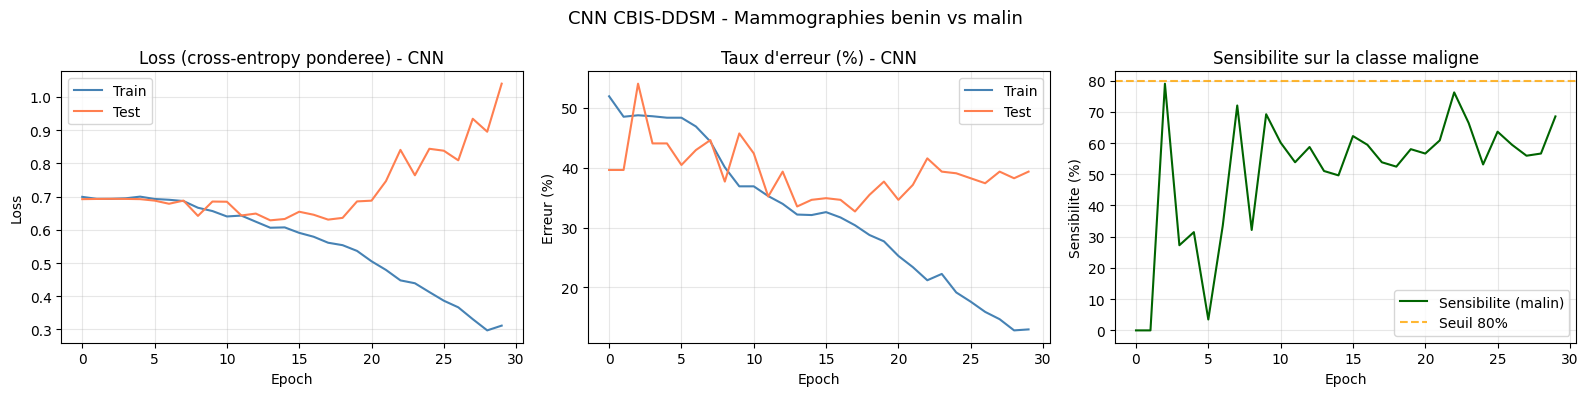

In [18]:
# Courbes d'apprentissage du CNN medical
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(hist_loss_tr, label="Train", color="steelblue")
ax1.plot(hist_loss_te, label="Test",  color="coral")
ax1.set_title("Loss (cross-entropy ponderee) - CNN")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot([e*100 for e in hist_err_tr], label="Train", color="steelblue")
ax2.plot([e*100 for e in hist_err_te], label="Test",  color="coral")
ax2.set_title("Taux d'erreur (%) - CNN")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Erreur (%)")
ax2.legend()
ax2.grid(alpha=0.3)

ax3.plot([s*100 for s in hist_sensib], color="darkgreen", label="Sensibilite (malin)")
ax3.axhline(y=80, color="orange", linestyle="--", alpha=0.8, label="Seuil 80%")
ax3.set_title("Sensibilite sur la classe maligne")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Sensibilite (%)")
ax3.legend()
ax3.grid(alpha=0.3)

plt.suptitle("CNN CBIS-DDSM - Mammographies benin vs malin", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_cnn_cbis.png", dpi=100, bbox_inches="tight")
plt.show()

---
## Section 3.4 - Analyse de la matrice de confusion et discussion médicale

En diagnostic médical, le taux d'erreur global est une métrique insuffisante.  
Il faut distinguer deux types d'erreurs aux conséquences très différentes :

| Erreur | Prediction | Realite | Consequence medicale |
|--------|-----------|---------|----------------------|
| **Faux negatif (FN)** | Benin (0) | Malin (1) | **Cancer manque → pronostic grave** |
| **Faux positif (FP)** | Malin (1) | Benin (0) | Fausse alarme → biopsie inutile, stress |

On calcule quatre métriques standard en screening :
$$\text{Sensibilite} = \frac{VP}{VP + FN} \qquad \text{Specificite} = \frac{VN}{VN + FP}$$
$$\text{VPP} = \frac{VP}{VP + FP} \qquad \text{VPN} = \frac{VN}{VN + FN}$$

In [19]:
# Collecte de toutes les predictions du CNN sur le test
model_cnn.eval()
all_preds  = []
all_probas = []

with torch.no_grad():
    for Xb, yb in test_loader:
        sortie = model_cnn(Xb)
        probas = torch.softmax(sortie, dim=1)
        preds  = probas.argmax(dim=1)
        all_preds.append(preds.numpy())
        all_probas.append(probas[:, 1].numpy())   # probabilite d'etre malin

y_pred        = np.concatenate(all_preds)
y_proba_malin = np.concatenate(all_probas)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
VN = cm[0, 0];  FP = cm[0, 1]
FN = cm[1, 0];  VP = cm[1, 1]

sensibilite = VP / (VP + FN + 1e-8)
specificite = VN / (VN + FP + 1e-8)
vpp         = VP / (VP + FP + 1e-8)
vpn         = VN / (VN + FN + 1e-8)
erreur_glob = (FP + FN) / len(y_test)

print("Matrice de confusion :")
print(f"                   Predit Benin   Predit Malin")
print(f"  Reel Benin  (0) :      {VN:4d}          {FP:4d}")
print(f"  Reel Malin  (1) :      {FN:4d}          {VP:4d}")
print()
print(f"Metriques medicales :")
print(f"  Sensibilite (rappel malin) : {sensibilite*100:.2f}%  <- VP / (VP + FN)")
print(f"  Specificite (rappel benin) : {specificite*100:.2f}%  <- VN / (VN + FP)")
print(f"  VPP                        : {vpp*100:.2f}%")
print(f"  VPN                        : {vpn*100:.2f}%")
print(f"  Erreur globale             : {erreur_glob*100:.2f}%")
print(f"\nFaux negatifs (cancers manques) : {FN} sur {VP+FN} cas malins reels")

Matrice de confusion :
                   Predit Benin   Predit Malin
  Reel Benin  (0) :       121            97
  Reel Malin  (1) :        45            98

Metriques medicales :
  Sensibilite (rappel malin) : 68.53%  <- VP / (VP + FN)
  Specificite (rappel benin) : 55.50%  <- VN / (VN + FP)
  VPP                        : 50.26%
  VPN                        : 72.89%
  Erreur globale             : 39.34%

Faux negatifs (cancers manques) : 45 sur 143 cas malins reels


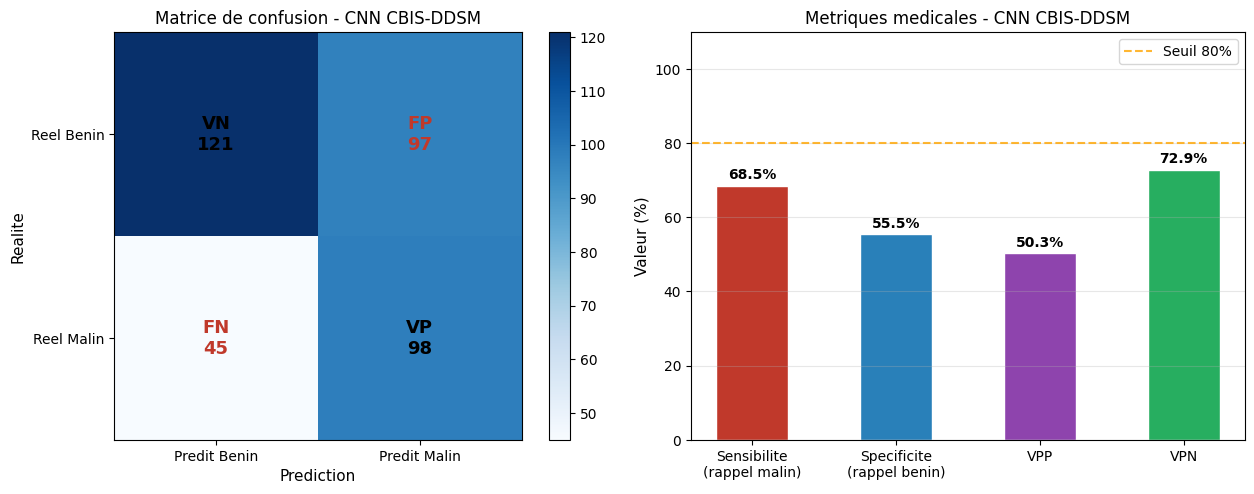

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matrice de confusion ---
ax = axes[0]
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predit Benin", "Predit Malin"], fontsize=10)
ax.set_yticklabels(["Reel Benin",   "Reel Malin"],   fontsize=10)
ax.set_xlabel("Prediction", fontsize=11)
ax.set_ylabel("Realite",    fontsize=11)
ax.set_title("Matrice de confusion - CNN CBIS-DDSM", fontsize=12)
for i, j, etiq, coul in [(0,0,f"VN\n{VN}","#000000"),(0,1,f"FP\n{FP}","#c0392b"),
                          (1,0,f"FN\n{FN}","#c0392b"),(1,1,f"VP\n{VP}","#000000")]:
    ax.text(j, i, etiq, ha="center", va="center", fontsize=13, fontweight="bold", color=coul)

# --- Barres des metriques ---
ax2     = axes[1]
noms    = ["Sensibilite\n(rappel malin)", "Specificite\n(rappel benin)", "VPP", "VPN"]
valeurs = [sensibilite*100, specificite*100, vpp*100, vpn*100]
coul    = ["#c0392b", "#2980b9", "#8e44ad", "#27ae60"]
barres  = ax2.bar(noms, valeurs, color=coul, edgecolor="white", width=0.5)
ax2.set_ylim(0, 110)
ax2.axhline(y=80, color="orange", linestyle="--", alpha=0.8, label="Seuil 80%")
ax2.set_ylabel("Valeur (%)", fontsize=11)
ax2.set_title("Metriques medicales - CNN CBIS-DDSM", fontsize=12)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
for barre, val in zip(barres, valeurs):
    ax2.text(barre.get_x() + barre.get_width()/2, val + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("matrice_confusion_cbis.png", dpi=100, bbox_inches="tight")
plt.show()

### Visualisation des erreurs du CNN

Faux negatifs (cancers manques) : 45
Faux positifs (fausses alarmes) : 97


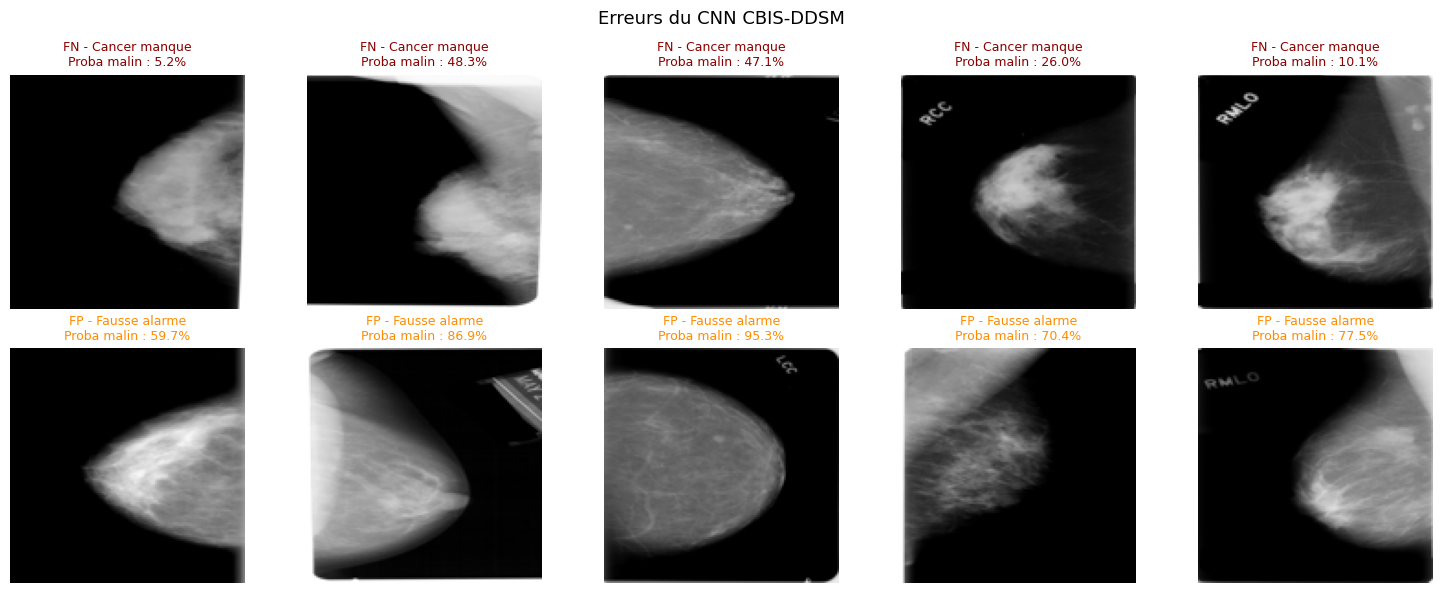

In [21]:
idx_fn = np.where((y_test == 1) & (y_pred == 0))[0]
idx_fp = np.where((y_test == 0) & (y_pred == 1))[0]

n_fn_affich = min(5, len(idx_fn))
n_fp_affich = min(5, len(idx_fp))

print(f"Faux negatifs (cancers manques) : {len(idx_fn)}")
print(f"Faux positifs (fausses alarmes) : {len(idx_fp)}")

if n_fn_affich > 0 or n_fp_affich > 0:
    n_cols = max(n_fn_affich, n_fp_affich, 1)
    fig, axes = plt.subplots(2, n_cols, figsize=(3*n_cols, 6))
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    for j in range(n_cols):
        if j < n_fn_affich:
            idx = idx_fn[j]
            axes[0][j].imshow(X_raw_test[idx], cmap="gray", vmin=0, vmax=1)
            axes[0][j].set_title(
                f"FN - Cancer manque\nProba malin : {y_proba_malin[idx]*100:.1f}%",
                fontsize=9, color="darkred")
        axes[0][j].axis("off")

        if j < n_fp_affich:
            idx = idx_fp[j]
            axes[1][j].imshow(X_raw_test[idx], cmap="gray", vmin=0, vmax=1)
            axes[1][j].set_title(
                f"FP - Fausse alarme\nProba malin : {y_proba_malin[idx]*100:.1f}%",
                fontsize=9, color="darkorange")
        axes[1][j].axis("off")

    plt.suptitle("Erreurs du CNN CBIS-DDSM", fontsize=13)
    plt.tight_layout()
    plt.savefig("erreurs_cnn_cbis.png", dpi=100, bbox_inches="tight")
    plt.show()

### Tableau comparatif final

In [22]:
def sensibilite_dense(X_flat, y, model_type, **params):
    """
    Calcule la sensibilite (rappel malin) pour un modele dense NumPy.

    X_flat     : (n, N_PIXELS)
    y          : (n,) etiquettes binaires
    model_type : 'lin', 'h1' ou 'h2'
    params     : poids et biais selon le modele
    Retourne   : float sensibilite
    """
    if model_type == "lin":
        o = X_flat @ params["A"].T + params["b"]
    elif model_type == "h1":
        z1 = np.maximum(0, X_flat @ params["A1"].T + params["b1"])
        o  = z1 @ params["A2"].T + params["b2"]
    elif model_type == "h2":
        z1 = np.maximum(0, X_flat @ params["A1"].T + params["b1"])
        z2 = np.maximum(0, z1 @ params["A2"].T + params["b2"])
        o  = z2 @ params["A3"].T + params["b3"]
    preds = np.argmax(o, axis=1)
    mask  = (y == 1)
    vp = int((preds[mask] == 1).sum())
    fn = int((preds[mask] == 0).sum())
    return vp / (vp + fn + 1e-8)


s_lin = sensibilite_dense(X_test_flat, y_test, "lin", A=A_lin, b=b_lin)
s_h1  = sensibilite_dense(X_test_flat, y_test, "h1",  A1=A1_h1, b1=b1_h1, A2=A2_h1, b2=b2_h1)
s_h2  = sensibilite_dense(X_test_flat, y_test, "h2",  A1=A1_h2, b1=b1_h2,
                           A2=A2_h2, b2=b2_h2, A3=A3_h2, b3=b3_h2)

print("=" * 75)
print(f"{'Modele':<25} {'Params':>12} {'Train':>8} {'Test':>8} {'Sensib.':>10}")
print("=" * 75)

configs = [
    ("Lineaire",      2*N_PIXELS+2,                      etr_lin[-1], ete_lin[-1], s_lin),
    ("H=1 (128)",     128*N_PIXELS+128+2*128+2,           etr_h1[-1],  ete_h1[-1],  s_h1),
    ("H=2 (128,64)",  128*N_PIXELS+128+64*128+64+2*64+2,  etr_h2[-1],  ete_h2[-1],  s_h2),
    ("CNN (PyTorch)", n_params, hist_err_tr[-1], hist_err_te[-1], sensibilite),
]

for modele, params, e_tr, e_te, s in configs:
    print(f"{modele:<25} {params:>12,} {e_tr*100:>7.2f}% {e_te*100:>7.2f}% {s*100:>9.1f}%")

print("=" * 75)
print("\nNote : la sensibilite (rappel malin) est la metrique prioritaire en diagnostic.")
print("Un faux negatif = cancer non detecte = retard de diagnostic potentiellement fatal.")

Modele                          Params    Train     Test    Sensib.
Lineaire                        32,770   49.39%   58.17%      95.8%
H=1 (128)                    2,097,538   25.67%   40.72%      60.8%
H=2 (128,64)                 2,105,666   48.50%   39.61%       0.0%
CNN (PyTorch)                  134,690   13.00%   39.34%      68.5%

Note : la sensibilite (rappel malin) est la metrique prioritaire en diagnostic.
Un faux negatif = cancer non detecte = retard de diagnostic potentiellement fatal.


### Discussion finale

#### Analyse des résultats obtenus

| Modèle | Params | Train | Test | Sensibilité |
|--------|--------|-------|------|-------------|
| Linéaire | 32 770 | 49.39% | 58.17% | 95.8% |
| H=1 (128) | 2 097 538 | 25.67% | 40.72% | 60.8% |
| H=2 (128,64) | 2 105 666 | 48.50% | 39.61% | 0.0% |
| CNN (PyTorch) | 134 690 | 13.00% | 39.34% | 68.5% |

#### Pourquoi le taux d'erreur global est une métrique trompeuse ici

Le premier réflexe est de comparer les taux d'erreur test : H=2 (39.61%), CNN (39.34%) et H=1 (40.72%) semblent proches. Ce serait une conclusion erronée. La sensibilité révèle que H=2 rate **100% des cancers** alors que le CNN en détecte **68.5%**. Ces deux modèles ne sont pas comparables malgré des taux d'erreur similaires.

C'est exactement pourquoi en diagnostic médical, la sensibilité prime sur le taux d'erreur global. Un modèle à 39% d'erreur qui prédit toujours "bénin" est inutilisable, tandis qu'un modèle à 40% d'erreur mais avec 68% de sensibilité a une vraie valeur clinique.

#### Analyse modèle par modèle

**Modèle linéaire : sensibilité 95.8% mais erreur test 58.17%.**  
Ce résultat paradoxal s'explique par l'absence de pondération dans la loss des modèles denses NumPy. Sans pénalisation des erreurs sur les malins, la descente de gradient a convergé vers une solution qui prédit quasi-systématiquement "malin". Cela maximise mécaniquement la sensibilité, mais au prix d'un taux de faux positifs massif : plus de la moitié des cas bénins sont classés malins. C'est médicalement inutilisable malgré la sensibilité apparente.

**H=2 : sensibilité 0.0% — il ne détecte aucun cancer.**  
C'est le phénomène inverse. Avec 2,1 millions de paramètres pour seulement 1231 images d'entraînement, H=2 a mémorisé les cas bénins majoritaires et prédit toujours "bénin". C'est le cas d'école de l'overfitting extrême amplifié par le déséquilibre des classes. Son taux d'erreur test de 39.6% semble raisonnable — c'est simplement le taux de cas malins dans le dataset de test (si tous sont prédits bénins, on se trompe exactement sur les malins). **Trop de paramètres tuent les paramètres**, comme on l'a déjà observé sur MNIST.

**H=1 : meilleur compromis parmi les modèles denses (sensibilité 60.8%).**  
Moins de paramètres que H=2 mais meilleure généralisation. La couche cachée de 128 neurones apprend suffisamment de structure sans mémoriser le dataset. H=1 bénéficie du même mécanisme qu'on a observé sur MNIST : au-delà d'un certain seuil, l'ajout de capacité nuit à la généralisation.

**CNN : meilleur modèle global (erreur test 39.34%, sensibilité 68.5%).**  
Avec seulement 134 690 paramètres — 15 fois moins que H=1 — le CNN obtient la meilleure erreur test et une sensibilité supérieure. Ce résultat confirme ce qu'on a observé sur CIFAR-10 : la convolution est structurellement plus efficace que les couches denses pour les images. Les filtres 3×3 détectent les mêmes textures (contours de masse, spiculations) quelle que soit leur position dans la mammographie, ce qu'un modèle dense ne peut pas faire car il traite chaque pixel comme une variable indépendante.

L'écart train/test du CNN (13% vs 39%) reste significatif et révèle de l'overfitting. Le Dropout(0.5) le réduit mais ne le supprime pas : avec seulement 1231 images, même un CNN relativement petit a suffisamment de capacité pour mémoriser les données d'entraînement.

#### Tous les modèles convergent vers ~40% d'erreur test

Ce plateau commun n'est pas un hasard. Le dataset de test contient 143 malins sur 361 images (39.6%). Un modèle qui prédit toujours "bénin" fait exactement 39.6% d'erreur. Le fait que tous nos modèles denses convergent vers cette valeur indique qu'aucun d'eux n'apprend vraiment la structure des données : ils oscillent autour du classifieur trivial. Seul le CNN parvient à se distinguer légèrement grâce à l'invariance par translation de la convolution.

#### Perspectives d'amélioration

Trois pistes auraient permis d'améliorer significativement ces résultats.

**Sur-échantillonnage pour les modèles denses.** Sans pondération native dans notre implémentation NumPy de la cross-entropy, les modèles denses n'équilibrent pas les classes. On aurait pu dupliquer les cas malins jusqu'à égalité avec les bénins avant l'entraînement. Cette technique simple aurait probablement résolu le problème de H=2 (sensibilité 0%) en forçant le gradient à prendre en compte les malins à chaque mini-batch.

**Data augmentation pour le CNN.** Avec seulement 1231 images, l'overfitting (13% train vs 39% test) est inévitable. Retourner horizontalement les mammographies — médicalement valide car gauche et droite sont symétriques — aurait doublé le dataset à 2462 images sans coût de collecte. Des rotations légères (±10°) et des variations de contraste auraient encore élargi la variabilité des exemples vus pendant l'entraînement.

**Travailler sur les ROI plutôt que les mammographies complètes.** Le CSV fournit `cropped image file path` qui pointe vers les régions d'intérêt (ROI) déjà découpées par les radiologues. Sur une mammographie complète, la lésion ne représente qu'une fraction des 128×128 pixels — la majorité du signal est du tissu sain sans information discriminante. Classifier directement les ROI permettrait au modèle de se concentrer sur les textures de la masse elle-même.